# 3D Print Failure Detection - YOLOv8 Training

Train a custom YOLOv8 model to detect 3D print failures (spaghetti, stringing, warping) using a dataset from Roboflow.

This notebook can run on:
- **Google Colab** (free GPU)
- **Jupyter Lab / Notebook** (local GPU)

## Steps
1. Install dependencies
2. Download dataset from Roboflow
3. Train YOLOv8 model
4. Evaluate and test
5. Export trained weights

## 1. Install Dependencies

In [ ]:
%pip install ultralytics roboflow -q

In [18]:
# Verify GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):,.2f} GB")
else:
    print("No GPU detected. Training will use CPU (much slower).")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.00 GB


## 2. Download Dataset from Roboflow

Using the **3D Print Failure Detection** dataset by max.
- Classes: spaghetti, stringing, warping
- Format: YOLOv8

Get your API key from [Roboflow Settings](https://app.roboflow.com/settings/api).

In [19]:
from roboflow import Roboflow
rf = Roboflow(api_key="BlvbG0T41lNSluwZdBag")
project = rf.workspace("bigvision-iwppy").project("3d-print-failure-detection-efvsh-cewsr")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 3d-print-failure-detection-1 in yolo26:: 100%|█| 9110/9110 [00:04<00:00, 2103.65it/s]


In [20]:
# Inspect dataset structure
import os

for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = "  " * (level + 1)
        for file in files[:5]:
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

3d-print-failure-detection-1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test/
    images/
    labels/
  train/
    images/
    labels/
  valid/
    images/
    labels/


In [21]:
# Read and display data.yaml
data_yaml_path = os.path.join(dataset.location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['spaghetti', 'stringing', 'warping']

roboflow:
  workspace: bigvision-iwppy
  project: 3d-print-failure-detection-efvsh-cewsr
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/bigvision-iwppy/3d-print-failure-detection-efvsh-cewsr/dataset/1


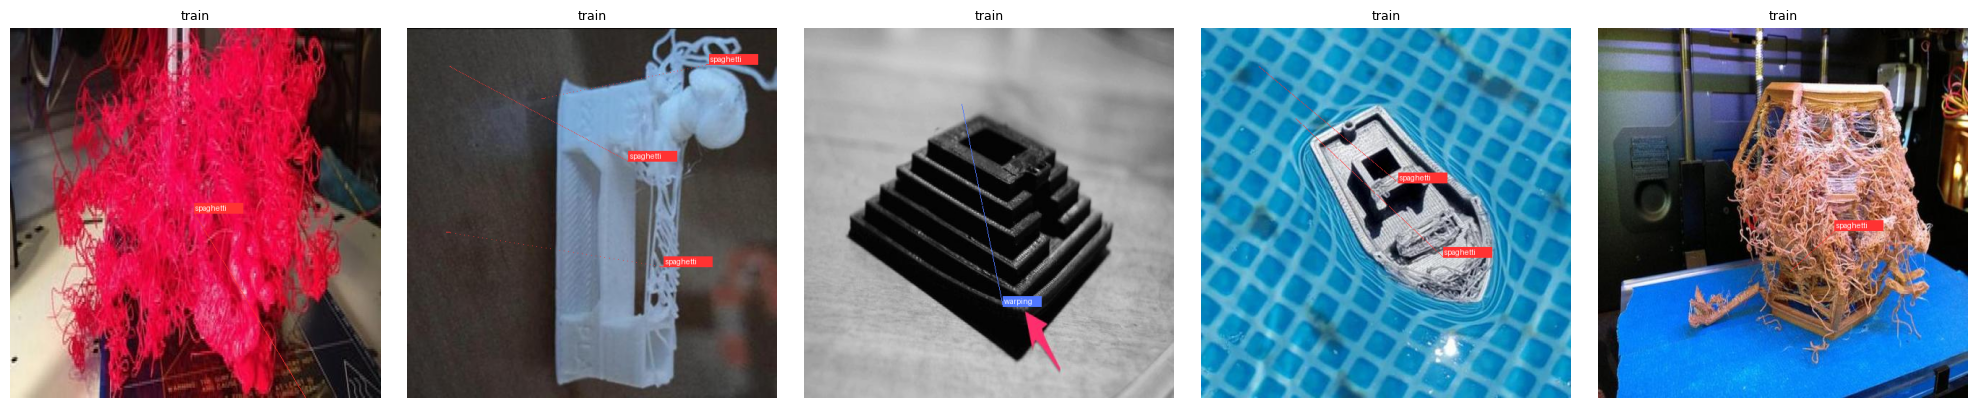

In [8]:
## Display some images
from img_display import show_samples

show_samples("3d-print-failure-detection-1/train")


## 3. Train YOLOv8 Model

We start with **YOLOv8n** (nano) — smallest and fastest variant.
Good enough for our use case (detecting large failures at low FPS).

Scale up to `yolov8s` or `yolov8m` if accuracy needs improvement.

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Train on our dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,            # Lower to 8 if you get OOM errors
    name="print_failure_detector",
    patience=10,         # Early stopping
    save=True,
    plots=True,
)

## 4. Evaluate the Model

In [ ]:
# Load the best weights
best_model = YOLO("runs/detect/print_failure_detector/weights/best.pt")

# Run validation
metrics = best_model.val()

print(f"\nmAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")

In [ ]:
# Display training results
from IPython.display import Image, display

# Training curves
results_img = "runs/detect/print_failure_detector/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img, width=800))
else:
    print(f"Results image not found at {results_img}")

In [ ]:
# Confusion matrix
cm_img = "runs/detect/print_failure_detector/confusion_matrix.png"
if os.path.exists(cm_img):
    display(Image(filename=cm_img, width=600))
else:
    print(f"Confusion matrix not found at {cm_img}")

## 5. Test on Sample Images

In [ ]:
import glob

# Pick a few test images
test_images = glob.glob(os.path.join(dataset.location, "test", "images", "*"))[:4]

if test_images:
    results = best_model(test_images)
    for i, result in enumerate(results):
        # Save annotated image
        result.save(filename=f"test_result_{i}.jpg")
        print(f"Image {i}: {len(result.boxes)} detections")
        for box in result.boxes:
            cls_name = best_model.names[int(box.cls[0])]
            conf = float(box.conf[0])
            print(f"  - {cls_name}: {conf:.2f}")
else:
    print("No test images found")

In [ ]:
# Display test results
for i in range(min(4, len(test_images))):
    img_path = f"test_result_{i}.jpg"
    if os.path.exists(img_path):
        display(Image(filename=img_path, width=500))
        print()

## 6. Export Model

The trained weights are saved at:
```
runs/detect/print_failure_detector/weights/best.pt
```

Download this file and place it in your `PrintFailureDetection/` directory to use with `print_monitor.py`.

In [ ]:
# Export to ONNX (optional, for deployment on edge devices)
# best_model.export(format="onnx")

print("Best weights location:")
weights_path = "runs/detect/print_failure_detector/weights/best.pt"
if os.path.exists(weights_path):
    size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"  {weights_path} ({size_mb:.1f} MB)")
else:
    print(f"  Weights not found at {weights_path}")

print("\nTraining complete! Download best.pt and run:")
print("  python print_monitor.py")

---

## Quick Reference

| Metric | What it means |
|--------|---------------|
| **mAP@0.5** | Accuracy at 50% IoU threshold (main metric) |
| **mAP@0.5:0.95** | Average accuracy across IoU thresholds |
| **Recall** | What fraction of real failures are detected |
| **Precision** | What fraction of detections are correct |

**Target:** mAP@0.5 > 0.7 for usable detection. Prioritize **high recall for spaghetti** (better to false alarm than miss a real failure).